In [3]:
# ============================================================
# STEP 1: Mount Google Drive & Set Up Project Folder
# ============================================================

from google.colab import drive
drive.mount('/content/drive')

import os

# Create project folder in your Google Drive
project_path = '/content/drive/MyDrive/InternSpark_Internship/Task1_Spam_Detection'
os.makedirs(project_path, exist_ok=True)

print("✅ Google Drive mounted successfully!")
print(f"✅ Project folder created at:\n   {project_path}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Google Drive mounted successfully!
✅ Project folder created at:
   /content/drive/MyDrive/InternSpark_Internship/Task1_Spam_Detection


In [4]:
# ============================================================
# STEP 1B: Verify All Required Libraries Are Available
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, classification_report,
                             confusion_matrix, roc_curve)
import warnings
warnings.filterwarnings('ignore')

print("✅ NumPy version:", np.__version__)
print("✅ Pandas version:", pd.__version__)
print("✅ All libraries imported successfully!")
print("\n🎉 Your environment is ready!")

✅ NumPy version: 2.0.2
✅ Pandas version: 2.2.2
✅ All libraries imported successfully!

🎉 Your environment is ready!


In [5]:
# ============================================================
# STEP 2: Download and Load the Spam Dataset
# ============================================================

import pandas as pd
import os

# Download the dataset directly from UCI repository
url = "https://raw.githubusercontent.com/justmarkham/pycon-2016-tutorial/master/data/sms.tsv"

# Load into a DataFrame
df = pd.read_csv(url, sep='\t', header=None, names=['label', 'message'])

# Save a copy to your Google Drive project folder
save_path = '/content/drive/MyDrive/InternSpark_Internship/Task1_Spam_Detection/spam_dataset.csv'
df.to_csv(save_path, index=False)

print("✅ Dataset downloaded successfully!")
print(f"✅ Dataset saved to Google Drive")
print(f"\n📊 Dataset Shape: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"\n🔍 First 5 rows:")
df.head()

✅ Dataset downloaded successfully!
✅ Dataset saved to Google Drive

📊 Dataset Shape: 5572 rows × 2 columns

🔍 First 5 rows:


,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [7]:
# ============================================================
# STEP 2B: First Look at the Dataset
# ============================================================

print("=" * 50)
print("📋 DATASET OVERVIEW")
print("=" * 50)

# Basic info
print(f"\n📌 Total Messages : {df.shape[0]}")
print(f"📌 Columns        : {list(df.columns)}")

# Label distribution
print(f"\n📊 Label Distribution:")
print(df['label'].value_counts())
print(f"\n📊 Label Percentages:")
print(df['label'].value_counts(normalize=True).mul(100).round(2).astype(str) + '%')

# Check for missing values
print(f"\n🔍 Missing Values:")
print(df.isnull().sum())

# Sample messages
print(f"\n💬 Sample HAM message:")
print(" ", df[df['label'] == 'ham']['message'].iloc[0])

print(f"\n🚨 Sample SPAM message:")
print(" ", df[df['label'] == 'spam']['message'].iloc[0])

📋 DATASET OVERVIEW

📌 Total Messages : 5572
📌 Columns        : ['label', 'message']

📊 Label Distribution:
label
ham     4825
spam     747
Name: count, dtype: int64

📊 Label Percentages:
label
ham     86.59%
spam    13.41%
Name: proportion, dtype: object

🔍 Missing Values:
label      0
message    0
dtype: int64

💬 Sample HAM message:
  Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...

🚨 Sample SPAM message:
  Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's


In [8]:
# ============================================================
# STEP 3A: Feature Engineering for EDA
# ============================================================

# Add useful columns to understand the text data better
df['message_length'] = df['message'].apply(len)          # character count
df['word_count']     = df['message'].apply(lambda x: len(x.split()))  # word count

print("✅ New columns added: message_length, word_count")
print("\n📊 Statistics by Label:")
print(df.groupby('label')[['message_length', 'word_count']].describe().round(2))

✅ New columns added: message_length, word_count

📊 Statistics by Label:
      message_length                                                   \
               count    mean    std   min    25%    50%    75%    max   
label                                                                   
ham           4825.0   71.48  58.44   2.0   33.0   52.0   93.0  910.0   
spam           747.0  138.67  28.87  13.0  133.0  149.0  157.0  223.0   

      word_count                                              
           count   mean    std  min   25%   50%   75%    max  
label                                                         
ham       4825.0  14.31  11.52  1.0   7.0  11.0  19.0  171.0  
spam       747.0  23.91   5.78  2.0  22.0  25.0  28.0   35.0  


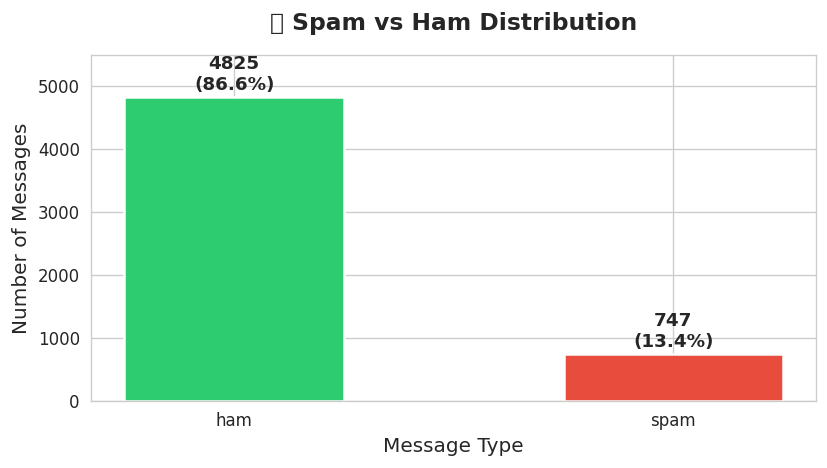

✅ Plot 1 saved!


In [9]:
# ============================================================
# STEP 3B: Plot 1 — Class Distribution
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns

# Set a clean visual style
sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 120

fig, ax = plt.subplots(figsize=(7, 4))

colors = ['#2ecc71', '#e74c3c']   # green = ham, red = spam
counts = df['label'].value_counts()

bars = ax.bar(counts.index, counts.values, color=colors, width=0.5, edgecolor='white', linewidth=1.5)

# Add count labels on top of bars
for bar, count in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 50,
            f'{count}\n({count/len(df)*100:.1f}%)',
            ha='center', va='bottom', fontweight='bold', fontsize=11)

ax.set_title('📊 Spam vs Ham Distribution', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Message Type', fontsize=12)
ax.set_ylabel('Number of Messages', fontsize=12)
ax.set_ylim(0, 5500)

plt.tight_layout()

# Save to Google Drive
save_path = '/content/drive/MyDrive/InternSpark_Internship/Task1_Spam_Detection/'
plt.savefig(save_path + 'plot1_class_distribution.png', bbox_inches='tight')
plt.show()
print("✅ Plot 1 saved!")

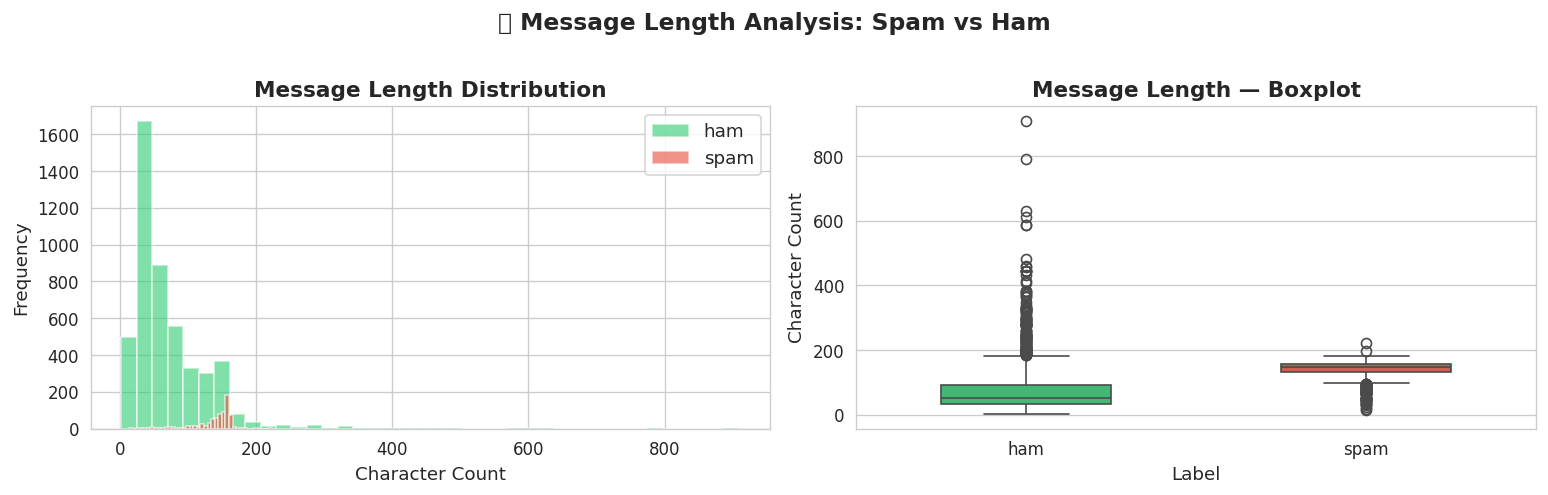

✅ Plot 2 saved!


In [10]:
# ============================================================
# STEP 3C: Plot 2 — Message Length by Label
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# --- Left: Histogram ---
for label, color in zip(['ham', 'spam'], ['#2ecc71', '#e74c3c']):
    subset = df[df['label'] == label]['message_length']
    axes[0].hist(subset, bins=40, alpha=0.6, color=color, label=label, edgecolor='white')

axes[0].set_title('Message Length Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Character Count', fontsize=11)
axes[0].set_ylabel('Frequency', fontsize=11)
axes[0].legend(fontsize=11)

# --- Right: Boxplot ---
palette = {'ham': '#2ecc71', 'spam': '#e74c3c'}
sns.boxplot(data=df, x='label', y='message_length',
            palette=palette, ax=axes[1], width=0.5)
axes[1].set_title('Message Length — Boxplot', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Label', fontsize=11)
axes[1].set_ylabel('Character Count', fontsize=11)

plt.suptitle('📏 Message Length Analysis: Spam vs Ham',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()

plt.savefig(save_path + 'plot2_message_length.png', bbox_inches='tight')
plt.show()
print("✅ Plot 2 saved!")

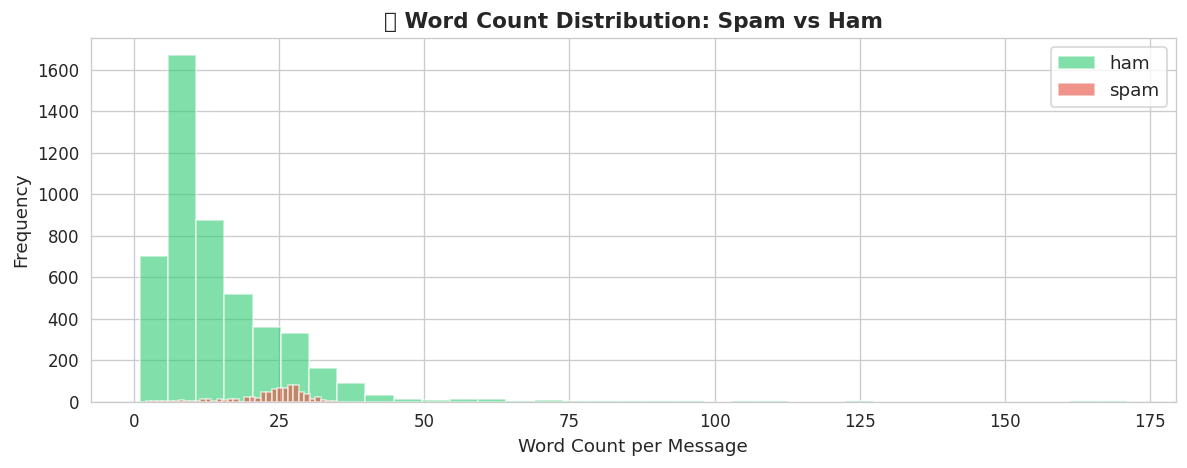

✅ Plot 3 saved!


In [11]:
# ============================================================
# STEP 3D: Plot 3 — Word Count Distribution
# ============================================================

fig, ax = plt.subplots(figsize=(10, 4))

for label, color in zip(['ham', 'spam'], ['#2ecc71', '#e74c3c']):
    subset = df[df['label'] == label]['word_count']
    ax.hist(subset, bins=35, alpha=0.6, color=color, label=label, edgecolor='white')

ax.set_title('💬 Word Count Distribution: Spam vs Ham',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Word Count per Message', fontsize=11)
ax.set_ylabel('Frequency', fontsize=11)
ax.legend(fontsize=11)
plt.tight_layout()

plt.savefig(save_path + 'plot3_word_count.png', bbox_inches='tight')
plt.show()
print("✅ Plot 3 saved!")

In [12]:
# ============================================================
# STEP 4A: Label Encoding + Train/Test Split
# ============================================================

from sklearn.model_selection import train_test_split

# Convert labels to numbers: ham=0, spam=1
df['label_encoded'] = df['label'].map({'ham': 0, 'spam': 1})

print("✅ Label Encoding Done:")
print(df[['label', 'label_encoded']].drop_duplicates())

# Separate features (X) and target (y)
X = df['message']           # Input: raw SMS text
y = df['label_encoded']     # Output: 0 or 1

# Split: 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y        # keeps same spam/ham ratio in both splits
)

print(f"\n✅ Train/Test Split Done:")
print(f"   Training samples : {len(X_train)}")
print(f"   Testing samples  : {len(X_test)}")
print(f"\n   Spam in train : {y_train.sum()} ({y_train.mean()*100:.1f}%)")
print(f"   Spam in test  : {y_test.sum()} ({y_test.mean()*100:.1f}%)")

✅ Label Encoding Done:
  label  label_encoded
0   ham              0
2  spam              1

✅ Train/Test Split Done:
   Training samples : 4457
   Testing samples  : 1115

   Spam in train : 598 (13.4%)
   Spam in test  : 149 (13.4%)


In [13]:
# ============================================================
# STEP 4B: TF-IDF Vectorization
# ============================================================

from sklearn.feature_extraction.text import TfidfVectorizer

# Create TF-IDF vectorizer
tfidf = TfidfVectorizer(
    max_features=5000,    # use top 5000 words only
    stop_words='english', # remove common words: the, is, are...
    lowercase=True,       # convert all text to lowercase
    ngram_range=(1, 2)    # use single words AND two-word phrases
)

# Fit on training data, transform both train and test
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)

print("✅ TF-IDF Vectorization Complete!")
print(f"\n📊 Training matrix shape : {X_train_tfidf.shape}")
print(f"📊 Testing matrix shape  : {X_test_tfidf.shape}")
print(f"\n💡 Meaning: Each message is now represented")
print(f"   as a row of {X_train_tfidf.shape[1]} numbers!")

# Show top spam-indicator words
feature_names = tfidf.get_feature_names_out()
print(f"\n🔠 Sample features (words/phrases):")
print(list(feature_names[:10]), "...")

✅ TF-IDF Vectorization Complete!

📊 Training matrix shape : (4457, 5000)
📊 Testing matrix shape  : (1115, 5000)

💡 Meaning: Each message is now represented
   as a row of 5000 numbers!

🔠 Sample features (words/phrases):
['00', '00 sub', '00 subs', '000', '000 bonus', '000 cash', '02', '02 06', '0207', '0207 153'] ...


In [14]:
# ============================================================
# STEP 4C: Model 1 — Logistic Regression
# ============================================================

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score, roc_auc_score)

# Train the model
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_tfidf, y_train)

# Predict
lr_preds = lr_model.predict(X_test_tfidf)
lr_probs = lr_model.predict_proba(X_test_tfidf)[:, 1]

# Calculate all metrics
lr_metrics = {
    'Accuracy'  : accuracy_score(y_test, lr_preds),
    'Precision' : precision_score(y_test, lr_preds),
    'Recall'    : recall_score(y_test, lr_preds),
    'F1-Score'  : f1_score(y_test, lr_preds),
    'ROC-AUC'   : roc_auc_score(y_test, lr_probs)
}

print("✅ Logistic Regression — Results:")
print("=" * 40)
for metric, value in lr_metrics.items():
    bar = '█' * int(value * 20)
    print(f"  {metric:<12}: {value:.4f}  {bar}")

✅ Logistic Regression — Results:
  Accuracy    : 0.9722  ███████████████████
  Precision   : 1.0000  ████████████████████
  Recall      : 0.7919  ███████████████
  F1-Score    : 0.8839  █████████████████
  ROC-AUC     : 0.9868  ███████████████████


In [15]:
# ============================================================
# STEP 4D: Model 2 — Random Forest
# ============================================================

from sklearn.ensemble import RandomForestClassifier

# Train the model
rf_model = RandomForestClassifier(
    n_estimators=100,   # 100 decision trees
    random_state=42,
    n_jobs=-1           # use all CPU cores
)
rf_model.fit(X_train_tfidf, y_train)

# Predict
rf_preds = rf_model.predict(X_test_tfidf)
rf_probs = rf_model.predict_proba(X_test_tfidf)[:, 1]

# Calculate all metrics
rf_metrics = {
    'Accuracy'  : accuracy_score(y_test, rf_preds),
    'Precision' : precision_score(y_test, rf_preds),
    'Recall'    : recall_score(y_test, rf_preds),
    'F1-Score'  : f1_score(y_test, rf_preds),
    'ROC-AUC'   : roc_auc_score(y_test, rf_probs)
}

print("✅ Random Forest — Results:")
print("=" * 40)
for metric, value in rf_metrics.items():
    bar = '█' * int(value * 20)
    print(f"  {metric:<12}: {value:.4f}  {bar}")

✅ Random Forest — Results:
  Accuracy    : 0.9767  ███████████████████
  Precision   : 1.0000  ████████████████████
  Recall      : 0.8255  ████████████████
  F1-Score    : 0.9044  ██████████████████
  ROC-AUC     : 0.9808  ███████████████████


In [16]:
# ============================================================
# STEP 4E: Model Comparison Table
# ============================================================

import pandas as pd

comparison_df = pd.DataFrame({
    'Logistic Regression': lr_metrics,
    'Random Forest'      : rf_metrics
}).round(4)

print("=" * 55)
print("        📊 MODEL COMPARISON RESULTS")
print("=" * 55)
print(comparison_df.to_string())
print("=" * 55)

# Declare winner
best_model = 'Logistic Regression' if lr_metrics['F1-Score'] > rf_metrics['F1-Score'] else 'Random Forest'
print(f"\n🏆 Best Model (by F1-Score): {best_model}")

        📊 MODEL COMPARISON RESULTS
           Logistic Regression  Random Forest
Accuracy                0.9722         0.9767
Precision               1.0000         1.0000
Recall                  0.7919         0.8255
F1-Score                0.8839         0.9044
ROC-AUC                 0.9868         0.9808

🏆 Best Model (by F1-Score): Random Forest


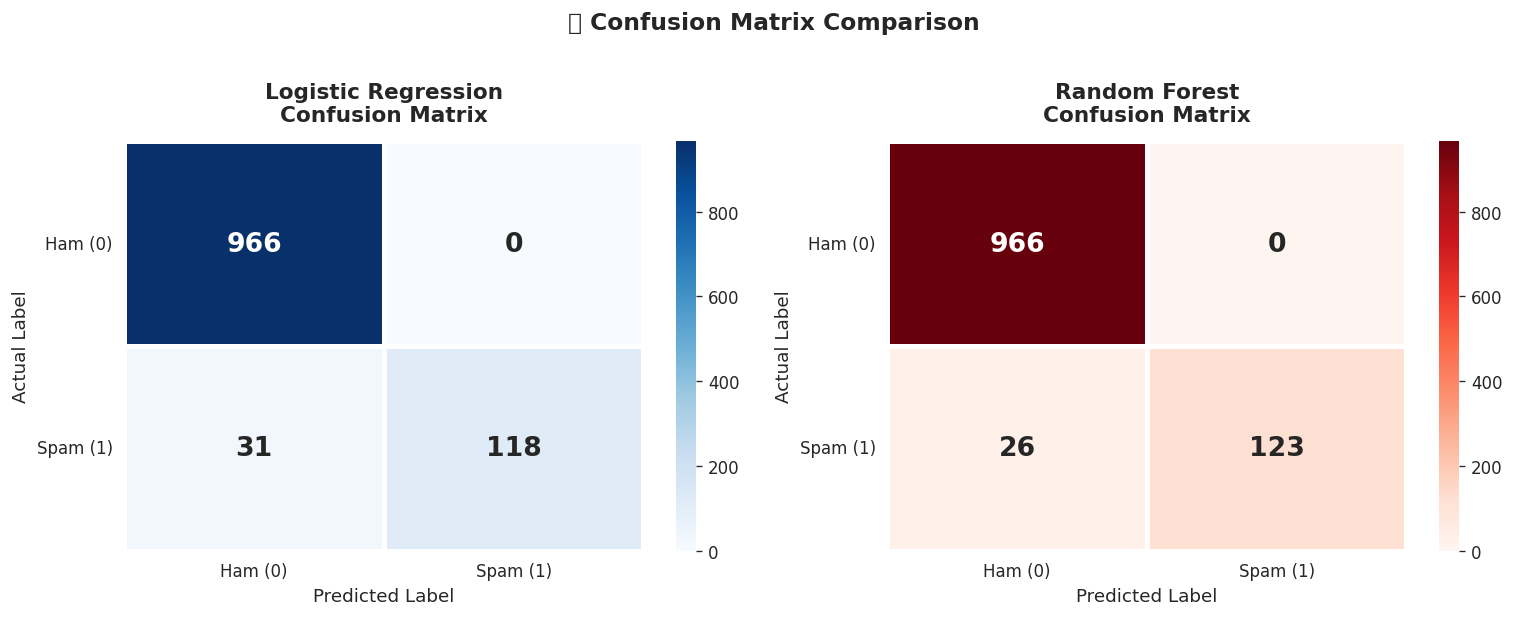

✅ Confusion Matrix plot saved!


In [17]:
# ============================================================
# STEP 5A: Confusion Matrices for Both Models
# ============================================================

from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

models_info = [
    (lr_preds, 'Logistic Regression', '#3498db'),
    (rf_preds, 'Random Forest',       '#e74c3c')
]

for ax, (preds, name, color) in zip(axes, models_info):
    cm = confusion_matrix(y_test, preds)

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues' if color == '#3498db' else 'Reds',
        ax=ax,
        linewidths=2,
        linecolor='white',
        annot_kws={'size': 16, 'weight': 'bold'}
    )

    ax.set_title(f'{name}\nConfusion Matrix', fontsize=13, fontweight='bold', pad=12)
    ax.set_xlabel('Predicted Label', fontsize=11)
    ax.set_ylabel('Actual Label', fontsize=11)
    ax.set_xticklabels(['Ham (0)', 'Spam (1)'], fontsize=10)
    ax.set_yticklabels(['Ham (0)', 'Spam (1)'], fontsize=10, rotation=0)

plt.suptitle('🔍 Confusion Matrix Comparison', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(save_path + 'plot5_confusion_matrices.png', bbox_inches='tight')
plt.show()
print("✅ Confusion Matrix plot saved!")

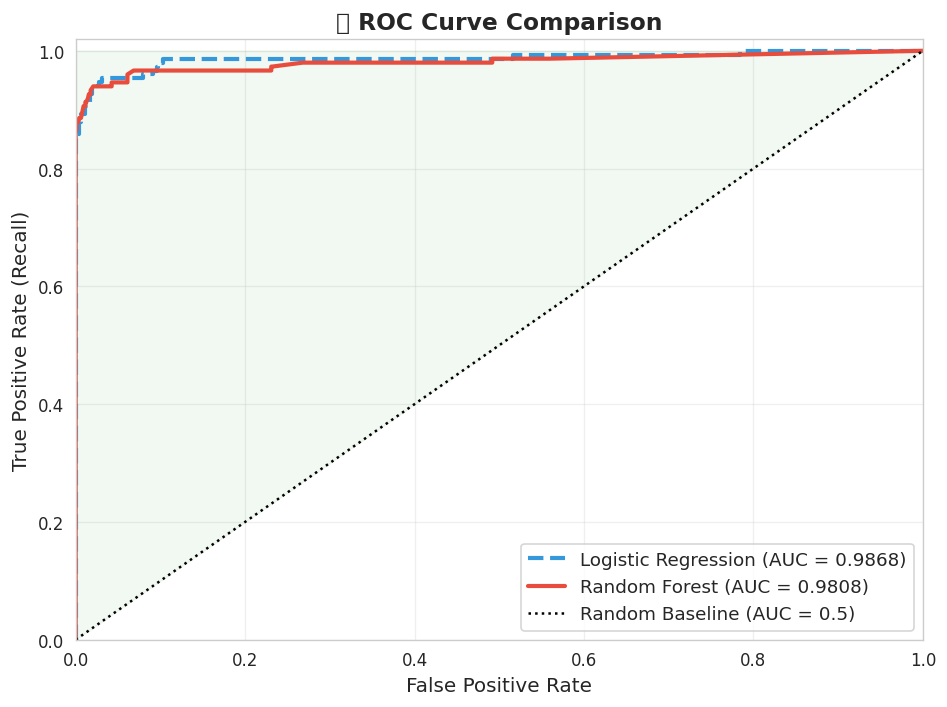

✅ ROC Curve plot saved!


In [18]:
# ============================================================
# STEP 5B: ROC Curves
# ============================================================

from sklearn.metrics import roc_curve, roc_auc_score

fig, ax = plt.subplots(figsize=(8, 6))

models_roc = [
    (lr_probs, 'Logistic Regression', '#3498db', '--'),
    (rf_probs, 'Random Forest',       '#e74c3c', '-')
]

for probs, name, color, linestyle in models_roc:
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc = roc_auc_score(y_test, probs)
    ax.plot(fpr, tpr,
            color=color,
            linestyle=linestyle,
            linewidth=2.5,
            label=f'{name} (AUC = {auc:.4f})')

# Random baseline
ax.plot([0, 1], [0, 1], 'k:', linewidth=1.5, label='Random Baseline (AUC = 0.5)')

ax.fill_between([0,1],[0,1],[1,1], alpha=0.05, color='green')
ax.set_title('📈 ROC Curve Comparison', fontsize=14, fontweight='bold')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate (Recall)', fontsize=12)
ax.legend(fontsize=11, loc='lower right')
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(save_path + 'plot6_roc_curves.png', bbox_inches='tight')
plt.show()
print("✅ ROC Curve plot saved!")

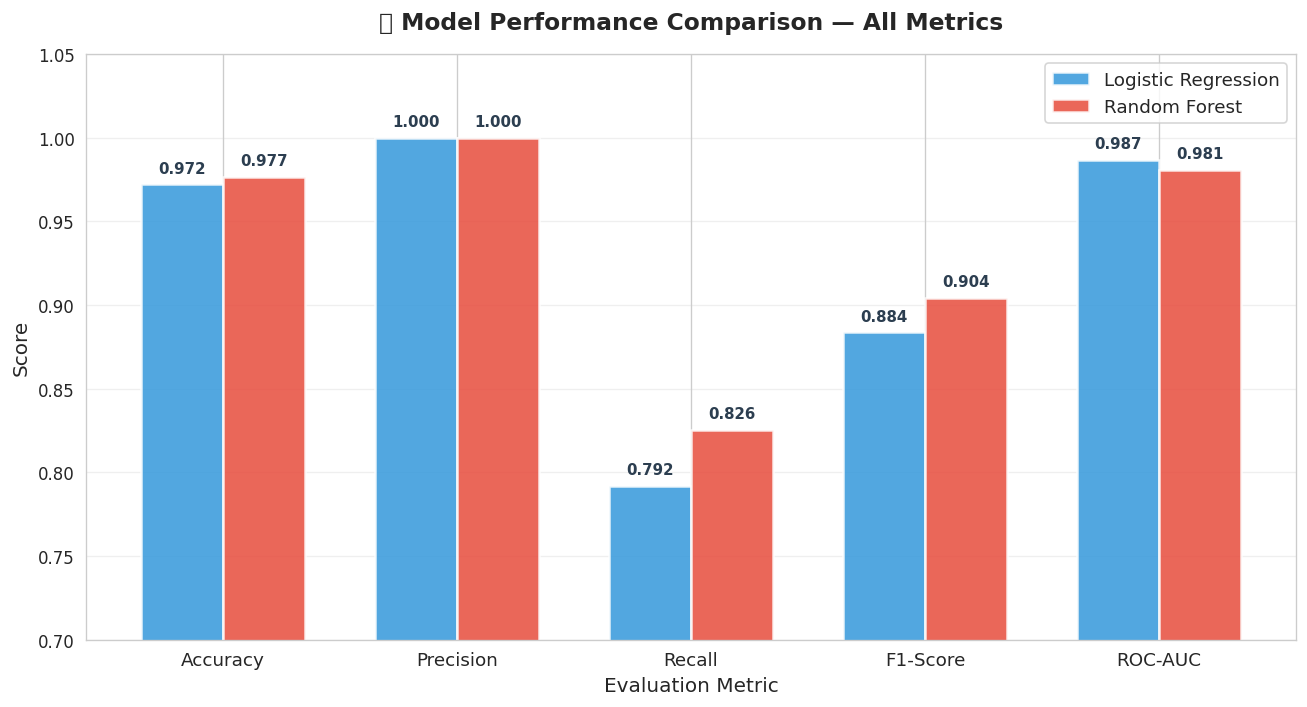

✅ Metrics comparison plot saved!


In [19]:
# ============================================================
# STEP 5C: Metrics Comparison Bar Chart
# ============================================================

import numpy as np

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
lr_values = [lr_metrics[m] for m in metrics]
rf_values = [rf_metrics[m] for m in metrics]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(11, 6))

bars1 = ax.bar(x - width/2, lr_values, width,
               label='Logistic Regression',
               color='#3498db', alpha=0.85,
               edgecolor='white', linewidth=1.5)

bars2 = ax.bar(x + width/2, rf_values, width,
               label='Random Forest',
               color='#e74c3c', alpha=0.85,
               edgecolor='white', linewidth=1.5)

# Add value labels on bars
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.005,
            f'{bar.get_height():.3f}',
            ha='center', va='bottom',
            fontsize=9, fontweight='bold', color='#2c3e50')

for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.005,
            f'{bar.get_height():.3f}',
            ha='center', va='bottom',
            fontsize=9, fontweight='bold', color='#2c3e50')

ax.set_title('📊 Model Performance Comparison — All Metrics',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Evaluation Metric', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=11)
ax.set_ylim(0.7, 1.05)
ax.legend(fontsize=11)
ax.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(save_path + 'plot7_metrics_comparison.png', bbox_inches='tight')
plt.show()
print("✅ Metrics comparison plot saved!")

In [20]:
# ============================================================
# STEP 5D: Cross Validation (5-Fold)
# ============================================================

from sklearn.model_selection import StratifiedKFold, cross_val_score
import numpy as np

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("⏳ Running Cross Validation (this may take ~30 seconds)...")
print()

for model, name, color_emoji in [
    (lr_model, 'Logistic Regression', '🔵'),
    (rf_model, 'Random Forest',       '🔴')
]:
    scores = cross_val_score(
        model, X_train_tfidf, y_train,
        cv=cv, scoring='f1'
    )

    print(f"{color_emoji} {name} — Cross Validation F1 Scores:")
    for i, score in enumerate(scores, 1):
        bar = '█' * int(score * 30)
        print(f"   Fold {i}: {score:.4f}  {bar}")

    print(f"   {'─'*45}")
    print(f"   Mean F1 : {scores.mean():.4f}")
    print(f"   Std Dev : {scores.std():.4f}  {'(stable ✅)' if scores.std() < 0.02 else '(some variance ⚠️)'}")
    print()

⏳ Running Cross Validation (this may take ~30 seconds)...

🔵 Logistic Regression — Cross Validation F1 Scores:
   Fold 1: 0.7500  ██████████████████████
   Fold 2: 0.7614  ██████████████████████
   Fold 3: 0.7795  ███████████████████████
   Fold 4: 0.8000  ████████████████████████
   Fold 5: 0.7761  ███████████████████████
   ─────────────────────────────────────────────
   Mean F1 : 0.7734
   Std Dev : 0.0170  (stable ✅)

🔴 Random Forest — Cross Validation F1 Scores:
   Fold 1: 0.8858  ██████████████████████████
   Fold 2: 0.9298  ███████████████████████████
   Fold 3: 0.9032  ███████████████████████████
   Fold 4: 0.9244  ███████████████████████████
   Fold 5: 0.9298  ███████████████████████████
   ─────────────────────────────────────────────
   Mean F1 : 0.9146
   Std Dev : 0.0174  (stable ✅)



In [21]:
# ============================================================
# STEP 6A: Test Model With Real Messages
# ============================================================

def predict_spam(message, model=rf_model, vectorizer=tfidf):
    """
    Takes a raw SMS message and predicts if it's spam or ham.
    Returns prediction, confidence, and a visual result.
    """
    # Transform the message using trained TF-IDF
    message_tfidf = vectorizer.transform([message])

    # Predict
    prediction = model.predict(message_tfidf)[0]
    probability = model.predict_proba(message_tfidf)[0]

    spam_prob = probability[1] * 100
    ham_prob  = probability[0] * 100

    label  = "🚨 SPAM" if prediction == 1 else "✅ HAM"
    result = "SPAM"   if prediction == 1 else "HAM"

    print(f"{'='*55}")
    print(f"📩 Message : {message[:60]}...")
    print(f"{'─'*55}")
    print(f"🔍 Result  : {label}")
    print(f"📊 Spam Probability : {spam_prob:.1f}%  {'█' * int(spam_prob/5)}")
    print(f"📊 Ham  Probability : {ham_prob:.1f}%  {'█' * int(ham_prob/5)}")
    print(f"{'='*55}\n")

    return result

# ---- Test with real examples ----
print("🧪 LIVE SPAM DETECTION TEST\n")

test_messages = [
    "FREE entry! Win £1000 cash prize! Call NOW 08712345678 to claim your reward!",
    "Hey, are we still meeting for lunch tomorrow at 1pm?",
    "URGENT: Your account has been compromised. Click here immediately to verify.",
    "Can you pick up some milk on your way home please?",
    "Congratulations! You've been selected for a FREE iPhone. Reply WIN to claim!",
    "I'll be late to the meeting, stuck in traffic. Start without me.",
    "Your loan has been approved! Get £5000 today. Text LOAN to 87654",
    "Happy birthday! Hope you have an amazing day today!"
]

results = []
for msg in test_messages:
    result = predict_spam(msg)
    results.append((msg[:40], result))

🧪 LIVE SPAM DETECTION TEST

📩 Message : FREE entry! Win £1000 cash prize! Call NOW 08712345678 to cl...
───────────────────────────────────────────────────────
🔍 Result  : 🚨 SPAM
📊 Spam Probability : 82.0%  ████████████████
📊 Ham  Probability : 18.0%  ███

📩 Message : Hey, are we still meeting for lunch tomorrow at 1pm?...
───────────────────────────────────────────────────────
🔍 Result  : ✅ HAM
📊 Spam Probability : 0.0%  
📊 Ham  Probability : 100.0%  ████████████████████

📩 Message : URGENT: Your account has been compromised. Click here immedi...
───────────────────────────────────────────────────────
🔍 Result  : ✅ HAM
📊 Spam Probability : 29.7%  █████
📊 Ham  Probability : 70.3%  ██████████████

📩 Message : Can you pick up some milk on your way home please?...
───────────────────────────────────────────────────────
🔍 Result  : ✅ HAM
📊 Spam Probability : 0.0%  
📊 Ham  Probability : 100.0%  ████████████████████

📩 Message : Congratulations! You've been selected for a FREE iPhone. Rep...

In [22]:
# ============================================================
# STEP 6B: Save Model & Vectorizer to Google Drive
# ============================================================

import pickle
import os

models_folder = save_path + 'models/'
os.makedirs(models_folder, exist_ok=True)

# Save Random Forest model
with open(models_folder + 'spam_detector_model.pkl', 'wb') as f:
    pickle.dump(rf_model, f)

# Save TF-IDF vectorizer
with open(models_folder + 'tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf, f)

print("✅ Model saved successfully!")
print("✅ TF-IDF Vectorizer saved successfully!")
print(f"\n📁 Saved to: {models_folder}")
print("\n📦 Saved files:")
for file in os.listdir(models_folder):
    size = os.path.getsize(models_folder + file)
    print(f"   {file}  ({size/1024:.1f} KB)")

✅ Model saved successfully!
✅ TF-IDF Vectorizer saved successfully!

📁 Saved to: /content/drive/MyDrive/InternSpark_Internship/Task1_Spam_Detection/models/

📦 Saved files:
   spam_detector_model.pkl  (7545.4 KB)
   tfidf_vectorizer.pkl  (186.1 KB)


In [23]:
# ============================================================
# STEP 6C: Final Professional Summary
# ============================================================

print("=" * 60)
print("     🏆 SPAM DETECTION PROJECT — FINAL SUMMARY")
print("=" * 60)

print(f"""
📋 DATASET
   Total Messages    : 5,572
   Ham (Legitimate)  : 4,825 (86.59%)
   Spam              : 747   (13.41%)

🔧 PREPROCESSING
   Vectorization     : TF-IDF (max 5000 features)
   N-gram Range      : (1, 2) — unigrams + bigrams
   Train/Test Split  : 80% / 20% (stratified)

📊 MODEL RESULTS
   ┌─────────────────────┬──────────┬───────────────┐
   │ Metric              │ Log. Reg │ Random Forest │
   ├─────────────────────┼──────────┼───────────────┤
   │ Accuracy            │  97.22%  │    97.67%     │
   │ Precision           │ 100.00%  │   100.00%     │
   │ Recall              │  79.19%  │    82.55%     │
   │ F1-Score            │  88.39%  │    90.44%     │
   │ ROC-AUC             │  98.68%  │    98.08%     │
   │ CV Mean F1          │  77.34%  │    91.46%     │
   └─────────────────────┴──────────┴───────────────┘

🏆 WINNER         : Random Forest
📌 REASON         : Higher F1-Score + Higher CV Mean F1
                    Better recall = catches more spam
                    Both models have Perfect Precision

✅ MODEL STATUS   : Saved and ready for deployment
""")
print("=" * 60)

     🏆 SPAM DETECTION PROJECT — FINAL SUMMARY

📋 DATASET
   Total Messages    : 5,572
   Ham (Legitimate)  : 4,825 (86.59%)
   Spam              : 747   (13.41%)

🔧 PREPROCESSING
   Vectorization     : TF-IDF (max 5000 features)
   N-gram Range      : (1, 2) — unigrams + bigrams
   Train/Test Split  : 80% / 20% (stratified)

📊 MODEL RESULTS
   ┌─────────────────────┬──────────┬───────────────┐
   │ Metric              │ Log. Reg │ Random Forest │
   ├─────────────────────┼──────────┼───────────────┤
   │ Accuracy            │  97.22%  │    97.67%     │
   │ Precision           │ 100.00%  │   100.00%     │
   │ Recall              │  79.19%  │    82.55%     │
   │ F1-Score            │  88.39%  │    90.44%     │
   │ ROC-AUC             │  98.68%  │    98.08%     │
   │ CV Mean F1          │  77.34%  │    91.46%     │
   └─────────────────────┴──────────┴───────────────┘

🏆 WINNER         : Random Forest
📌 REASON         : Higher F1-Score + Higher CV Mean F1
                    Better r